# One-Class SVM — Hyperparameter Comparison

This notebook follows the same workflow as `one_class_svm.ipynb` but runs the model across **6 hyperparameter configurations** to compare their performance.

**Configurations tested:**

| # | nu | gamma | Rationale |
|---|---|---|---|
| 1 | 0.01 | scale | Very tight boundary — default gamma |
| 2 | 0.05 | scale | Baseline — default settings |
| 3 | 0.10 | scale | Relaxed boundary — default gamma |
| 4 | 0.20 | scale | Loose boundary — default gamma |
| 5 | 0.05 | auto | Baseline nu — broader kernel bandwidth |
| 6 | 0.05 | 0.001 | Baseline nu — very smooth, wide boundary |

**What we are varying:**
- **nu** — controls how tightly the boundary wraps around the normal data. Configs 1–4 isolate this effect with `gamma='scale'` fixed. Smaller nu = tighter fit, fewer allowed training errors.
- **gamma** — controls the shape of the RBF kernel. `'scale'` uses `1 / (n_features × std)`, `'auto'` uses `1 / n_features`, and `0.001` is a manually set small value producing a very smooth, wide boundary. Configs 2, 5, 6 isolate this effect with `nu=0.05` fixed.

**kernel is fixed at `'rbf'`** and **threshold is fixed at the top 5%** of normal training scores across all configurations.

## 1. Hyperparameter Grid

All configurations are defined here. Add or remove entries to experiment with other values.

In [1]:
# ── Define all hyperparameter combinations to compare ───────────────────────

CONFIGS = [
    {'nu': 0.01, 'gamma': 'scale'},
    {'nu': 0.05, 'gamma': 'scale'},
    {'nu': 0.10, 'gamma': 'scale'},
    {'nu': 0.20, 'gamma': 'scale'},
    {'nu': 0.05, 'gamma': 'auto'},
    {'nu': 0.05, 'gamma': 0.001},
]

KERNEL               = 'rbf'
THRESHOLD_PERCENTILE = 5
TEST_SIZE            = 0.20
RANDOM_STATE         = 42

# ─────────────────────────────────────────────────────────────────────────────

print(f'{len(CONFIGS)} configurations to evaluate (kernel={KERNEL!r}, threshold_percentile={THRESHOLD_PERCENTILE}):')
for i, c in enumerate(CONFIGS, 1):
    print(f'  [{i}] nu={c["nu"]:<5}  gamma={str(c["gamma"])}')

6 configurations to evaluate (kernel='rbf', threshold_percentile=5):
  [1] nu=0.01   gamma=scale
  [2] nu=0.05   gamma=scale
  [3] nu=0.1    gamma=scale
  [4] nu=0.2    gamma=scale
  [5] nu=0.05   gamma=auto
  [6] nu=0.05   gamma=0.001


## 2. Imports

Loading all libraries needed for the One-Class SVM model, evaluation metrics, and plotting.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import OneClassSVM
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

np.random.seed(42)

## 3. Load Data and Split

`all_spectra.csv` is split 80/20:
- **Train set (80%)** — used to fit the One-Class SVM and derive the decision threshold.
- **Test set (20% normal + all 55 ambient)** — used for evaluation only; neither split was seen during fitting.

A random split is used (no stratification) because some polymer classes have only 1 sample.

In [3]:
all_spectra     = pd.read_csv('../data/all_spectra.csv',     index_col=0)
ambient_spectra = pd.read_csv('../data/ambient_spectra.csv', index_col=0)

label_col   = 'polymer'
wavelengths = [c for c in all_spectra.columns if c != label_col]

X_all     = all_spectra[wavelengths].values
X_anomaly = ambient_spectra[wavelengths].values  # (55, 535)

# Random 80/20 split — no stratification because some classes have only 1 sample
X_train, X_test_normal = train_test_split(
    X_all,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

# Test set = held-out normal + ambient anomalies
y_test = np.concatenate([
    np.zeros(len(X_test_normal)),
    np.ones(len(X_anomaly))
])

print('── Dataset Split ──────────────────────────────────────────')
print(f'  all_spectra total          : {X_all.shape}')
print(f'  Training set (80%)         : {X_train.shape}')
print(f'  Test normal  (20%)         : {X_test_normal.shape}')
print(f'  Test anomaly (ambient)     : {X_anomaly.shape}')
print(f'  Test set total             : ({len(X_test_normal) + len(X_anomaly)}, {X_all.shape[1]})')
print('───────────────────────────────────────────────────────────')

── Dataset Split ──────────────────────────────────────────
  all_spectra total          : (1215, 535)
  Training set (80%)         : (972, 535)
  Test normal  (20%)         : (243, 535)
  Test anomaly (ambient)     : (55, 535)
  Test set total             : (298, 535)
───────────────────────────────────────────────────────────


## 4. Run All Configurations

For each configuration, the following steps are performed (identical to `one_class_svm.ipynb`):
1. Train `OneClassSVM` on normal samples only
2. Compute anomaly scores using `decision_function()`, negated so higher = more anomalous
3. Set the decision threshold at the top `THRESHOLD_PERCENTILE` of normal scores
4. Predict labels and compute evaluation metrics

All results are stored in a list for plotting and comparison.

**Note:** One-Class SVM is slower than tree-based models. Each fit may take 10–60 seconds on this dataset.

In [4]:
results = []

for cfg in CONFIGS:
    nu    = cfg['nu']
    gamma = cfg['gamma']
    label = f"nu={nu}, γ={gamma}"

    # Fit on training set only
    oc_svm = OneClassSVM(nu=nu, kernel=KERNEL, gamma=gamma)
    oc_svm.fit(X_train)

    # Training scores — used to set the decision threshold
    scores_train = -oc_svm.decision_function(X_train)
    threshold    = np.percentile(scores_train, 100 - THRESHOLD_PERCENTILE)

    # Test scores
    scores_normal  = -oc_svm.decision_function(X_test_normal)
    scores_anomaly = -oc_svm.decision_function(X_anomaly)

    # Combine and predict
    all_scores  = np.concatenate([scores_normal, scores_anomaly])
    pred_labels = (all_scores > threshold).astype(int)

    roc_auc     = roc_auc_score(y_test, all_scores)
    cm          = confusion_matrix(y_test, pred_labels)
    fpr, tpr, _ = roc_curve(y_test, all_scores)
    tn, fp, fn, tp = cm.ravel()
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    n_support = oc_svm.support_vectors_.shape[0]

    results.append({
        'label':          label,
        'nu':             nu,
        'gamma':          gamma,
        'threshold':      threshold,
        'scores_normal':  scores_normal,
        'scores_anomaly': scores_anomaly,
        'all_scores':     all_scores,
        'pred_labels':    pred_labels,
        'roc_auc':        roc_auc,
        'cm':             cm,
        'fpr':            fpr,
        'tpr':            tpr,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'recall':         recall,
        'precision':      precision,
        'n_support':      n_support,
    })

    print(f'[{label}]  AUC={roc_auc:.3f}  TP={tp}  FN={fn}  FP={fp}  TN={tn}  Recall={recall:.2f}  Support Vectors={n_support}')

print('\nDone.')

[nu=0.01, γ=scale]  AUC=0.892  TP=43  FN=12  FP=39  TN=204  Recall=0.78  Support Vectors=121
[nu=0.05, γ=scale]  AUC=0.892  TP=43  FN=12  FP=39  TN=204  Recall=0.78  Support Vectors=121
[nu=0.1, γ=scale]  AUC=0.887  TP=41  FN=14  FP=28  TN=215  Recall=0.75  Support Vectors=130
[nu=0.2, γ=scale]  AUC=0.853  TP=9  FN=46  FP=15  TN=228  Recall=0.16  Support Vectors=207
[nu=0.05, γ=auto]  AUC=0.892  TP=43  FN=12  FP=39  TN=204  Recall=0.78  Support Vectors=121
[nu=0.05, γ=0.001]  AUC=0.906  TP=44  FN=11  FP=29  TN=214  Recall=0.80  Support Vectors=109

Done.


## 5. Anomaly Score Distributions

One histogram per configuration. Blue bars are normal samples, orange are ambient (anomaly) samples, and the red dashed line is the decision threshold.

**What to look for:** configurations where the orange and blue distributions are most separated indicate a better-performing model.

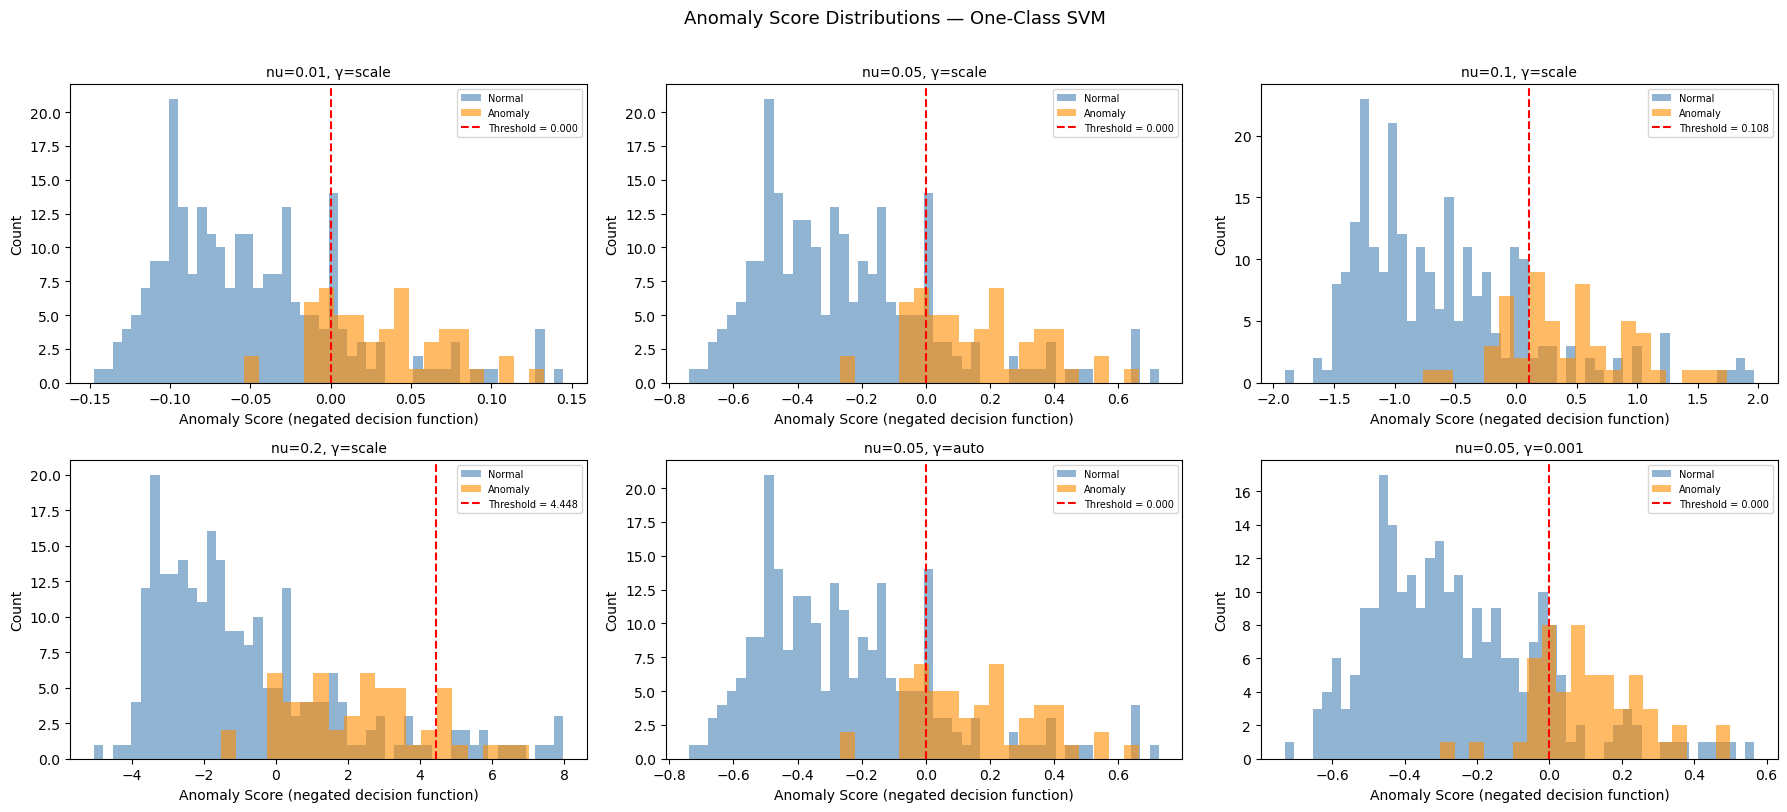

In [5]:
import os
os.makedirs('../figures', exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, r in enumerate(results):
    ax = axes[i]

    ax.hist(r['scores_normal'],  bins=50, alpha=0.6, color='steelblue',  label='Normal')
    ax.hist(r['scores_anomaly'], bins=20, alpha=0.6, color='darkorange', label='Anomaly')
    ax.axvline(r['threshold'], color='red', linestyle='--', linewidth=1.5,
               label=f'Threshold = {r["threshold"]:.3f}')

    ax.set_title(r['label'], fontsize=10)
    ax.set_xlabel('Anomaly Score (negated decision function)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

plt.suptitle('Anomaly Score Distributions — One-Class SVM', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../figures/ocsvm_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Results:**

Across all configurations, the normal (blue) distribution is concentrated on the left (lower anomaly scores) and the anomaly (orange) distribution is shifted rightward, but the two classes overlap considerably — typical for one-class anomaly detection on spectral data.

- **nu=0.01, nu=0.05 (γ=scale), and nu=0.05 (γ=auto):** All three produce an identical, narrow score range with the threshold sitting at exactly 0.000. Normal samples are tightly packed just below zero and anomalies cluster near zero with a moderate tail above it. The threshold provides some separation but leaves a substantial overlap region.

- **nu=0.1 (γ=scale):** The score range widens (≈−2.0 to 2.0) and the threshold rises to 0.108. The distributions become more spread out, and the anomaly tail above the threshold shrinks — the looser boundary begins absorbing some anomaly structure, slightly reducing sensitivity (Recall drops from 0.782 to 0.745).

- **nu=0.2 (γ=scale):** The score range explodes (≈−5 to 8) with the threshold jumping to 4.448. Nearly all anomaly samples fall well below this high threshold, causing a near-complete recall collapse (Recall = 0.164). The very loose boundary has effectively absorbed most anomalies into the "normal" region.

- **nu=0.05 (γ=auto):** The distribution is nearly identical to nu=0.05 (γ=scale), confirming that `auto` and `scale` produce very similar kernel bandwidths and score profiles on this dataset.

- **nu=0.05 (γ=0.001):** Score range is compact (≈−0.7 to 0.6) with threshold at 0.000. The anomaly distribution shows the most rightward shift of all configurations, yielding the cleanest visual separation and the best AUC (0.906) and Recall (0.800).

## 6. Confusion Matrices

One confusion matrix per configuration, labeled with TN, FP, FN, TP.

**What to look for:** high TP (anomalies correctly caught) and low FN (anomalies missed). FN is the most costly error in anomaly detection.

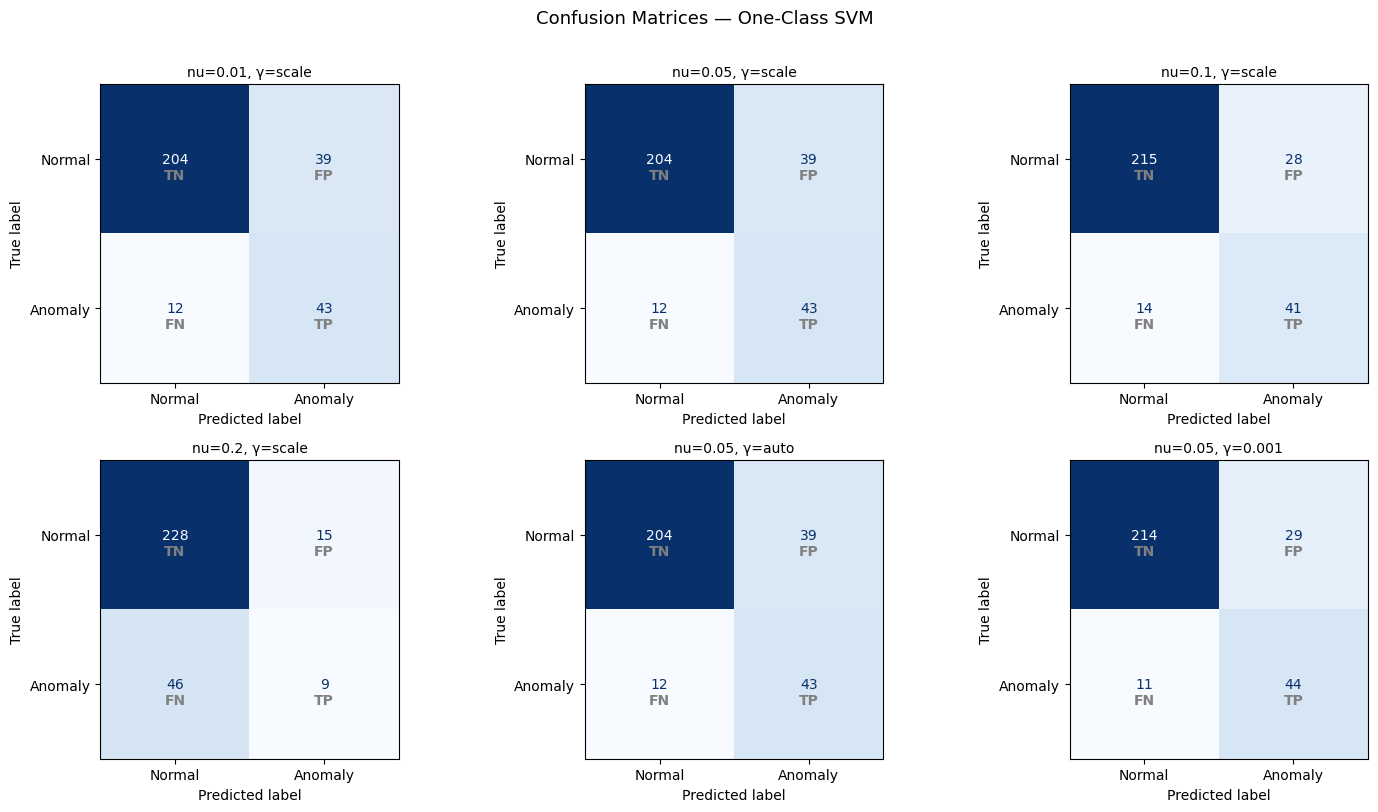

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

cell_labels = [['TN', 'FP'], ['FN', 'TP']]

for i, r in enumerate(results):
    ax = axes[i]

    disp = ConfusionMatrixDisplay(confusion_matrix=r['cm'], display_labels=['Normal', 'Anomaly'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')

    for row in range(2):
        for col in range(2):
            ax.text(col, row, f'\n\n{cell_labels[row][col]}', ha='center', va='center',
                    fontsize=10, fontweight='bold', color='gray')

    ax.set_title(r['label'], fontsize=10)

plt.suptitle('Confusion Matrices — One-Class SVM', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../figures/ocsvm_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

**Results:**

The confusion matrices reveal two distinct failure modes across the six configurations: missed anomalies (high FN) from too-loose boundaries, and excess false alarms (high FP) from tight boundaries that still struggle with overlap.

- **nu=0.05, γ=0.001 (best):** TP=44, FN=11, FP=29, TN=214, Recall=0.800, Precision=0.603. The only configuration to detect more than 80% of anomalies. Uses 109 support vectors — the fewest of all configurations, indicating a tighter, more focused boundary.

- **nu=0.01, nu=0.05 (γ=scale), and nu=0.05 (γ=auto):** All three produce identical matrices — TP=43, FN=12, FP=39, TN=204, Recall=0.782. These configurations are functionally equivalent on this dataset. Their FP count (39) is notably higher than γ=0.001 (29), making them less precise.

- **nu=0.1 (γ=scale):** TP=41, FN=14, FP=28, TN=215, Recall=0.745. Interestingly, FP drops to 28 (lower than the tight-nu configs), but 3 more anomalies are missed compared to the best group. The relaxed boundary shifts the threshold higher, flagging fewer normals but also missing more anomalies — a classic precision–recall tradeoff.

- **nu=0.2 (γ=scale):** A clear failure — TP=9, FN=46, FP=15, TN=228, Recall=0.164. Only 9 of 55 anomalies are detected. The very loose boundary (207 support vectors) wraps around so much of the data space that anomaly samples score as normal. Despite having the lowest FP count, it is the worst configuration due to catastrophic recall collapse.

**Takeaway:** nu is the dominant control on recall. Keeping nu ≤ 0.05 is essential; nu=0.2 loses 80% of anomaly detections. A small fixed gamma (γ=0.001) gives a slight but consistent improvement over scale/auto — catching one more anomaly while also reducing false positives by 10.

## 7. ROC Curves

All 6 ROC curves on one chart for easy comparison. A curve closer to the top-left corner means better performance. The gray dashed diagonal is the random baseline (AUC = 0.5).

**What to look for:** the configuration with the highest AUC has the best threshold-independent separation ability.

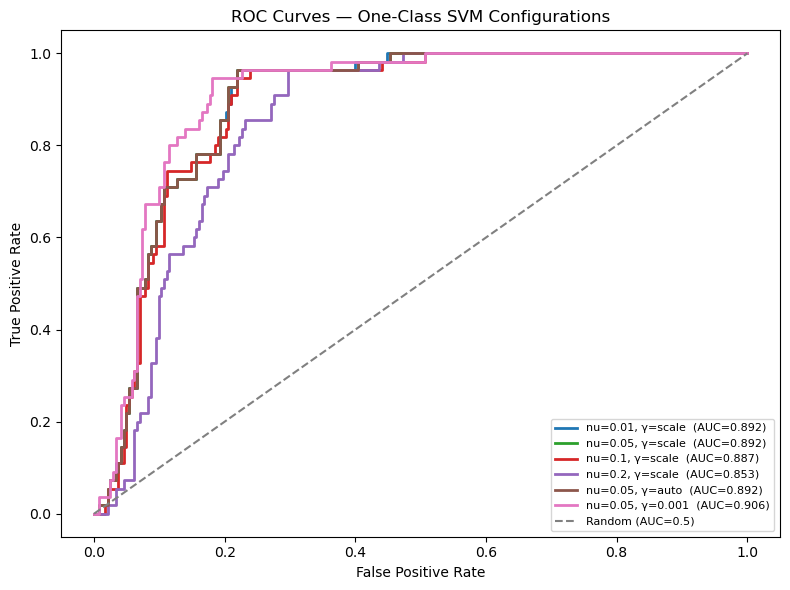

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

for i, r in enumerate(results):
    ax.plot(r['fpr'], r['tpr'], lw=2, color=colors[i],
            label=f"{r['label']}  (AUC={r['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random (AUC=0.5)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — One-Class SVM Configurations')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('../figures/ocsvm_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

**Results:**

All six configurations substantially outperform the random baseline (AUC=0.5), confirming that One-Class SVM captures genuine discriminative structure in the spectral data. However, the spread between best and worst (AUC 0.853–0.906) is meaningful.

- **nu=0.05, γ=0.001 (AUC=0.906):** The clear winner. Its ROC curve rises most steeply at low FPR, meaning it can catch a high fraction of anomalies while flagging very few normal samples. The smooth, wide RBF kernel created by the tiny gamma value produces the most informative anomaly scores.

- **nu=0.01, nu=0.05 (γ=scale), and nu=0.05 (γ=auto) (AUC=0.892):** These three curves are nearly indistinguishable — matching the equivalence seen in the confusion matrices. They form a tight cluster just below the γ=0.001 curve throughout the low-FPR range.

- **nu=0.1 (γ=scale) (AUC=0.887):** A small but visible step down. The curve tracks closely with the AUC=0.892 group until around FPR≈0.15, then diverges slightly — reflecting that the looser boundary assigns overlapping scores to more of the anomaly population.

- **nu=0.2 (γ=scale) (AUC=0.853):** The clear outlier. The curve rises more slowly and never reaches the top-left corner as closely as the others, showing that the very loose boundary produces fundamentally weaker score separation across all possible thresholds — not just the chosen operating point.

**Takeaway:** The ROC analysis confirms that γ=0.001 is the single most impactful change tested — it improves AUC by 1.4 points over the γ=scale/auto group while also boosting recall and precision. Increasing nu beyond 0.1 is detrimental regardless of threshold choice.

## 8. Summary Table

A single table summarising all key metrics across every configuration, sorted by AUC descending.

- **AUC** — threshold-independent ranking ability (higher is better)
- **TP** — anomalies correctly caught (higher is better)
- **FN** — anomalies missed (lower is better)
- **FP** — normal samples falsely flagged (lower is better)
- **Recall** — TP / (TP + FN), fraction of anomalies detected
- **Precision** — TP / (TP + FP), fraction of flagged samples that are real anomalies
- **Support Vectors** — number of training samples on or near the boundary

In [8]:
summary = pd.DataFrame([{
    'Configuration':   r['label'],
    'nu':              r['nu'],
    'gamma':           str(r['gamma']),
    'Threshold':       round(r['threshold'], 4),
    'AUC':             round(r['roc_auc'], 3),
    'TP':              int(r['tp']),
    'FN':              int(r['fn']),
    'FP':              int(r['fp']),
    'TN':              int(r['tn']),
    'Recall':          round(r['recall'], 3),
    'Precision':       round(r['precision'], 3),
    'Support Vectors': int(r['n_support']),
} for r in results])

summary = summary.sort_values('AUC', ascending=False).reset_index(drop=True)
display(summary)

,Configuration,nu,gamma,Threshold,AUC,TP,FN,FP,TN,Recall,Precision,Support Vectors
0,"nu=0.05, γ=0.001",0.05,0.001,0.0001,0.906,44,11,29,214,0.800,0.603,109
1,"nu=0.01, γ=scale",0.01,scale,0.0000,0.892,43,12,39,204,0.782,0.524,121
2,"nu=0.05, γ=scale",0.05,scale,0.0000,0.892,43,12,39,204,0.782,0.524,121
3,"nu=0.05, γ=auto",0.05,auto,0.0000,0.892,43,12,39,204,0.782,0.524,121
4,"nu=0.1, γ=scale",0.10,scale,0.1077,0.887,41,14,28,215,0.745,0.594,130
5,"nu=0.2, γ=scale",0.20,scale,4.4475,0.853,9,46,15,228,0.164,0.375,207


**Results:**

| Rank | Configuration | AUC | Recall | Precision | TP | FN | FP |
|------|--------------|-----|--------|-----------|----|----|-----|
| 1 | nu=0.05, γ=0.001 | **0.906** | **0.800** | **0.603** | **44** | **11** | 29 |
| 2–4 | nu=0.01/0.05, γ=scale/auto | 0.892 | 0.782 | 0.524 | 43 | 12 | 39 |
| 5 | nu=0.1, γ=scale | 0.887 | 0.745 | 0.594 | 41 | 14 | **28** |
| 6 | nu=0.2, γ=scale | 0.853 | 0.164 | 0.375 | 9 | 46 | 15 |

**Best configuration: nu=0.05, γ=0.001** — highest AUC (0.906), highest recall (0.800), highest precision (0.603), and fewest support vectors (109). This configuration detects 44 of 55 ambient anomalies while keeping false alarms to 29 out of 243 normal test samples.

**Key findings:**

1. **γ drives the biggest single improvement.** Setting γ=0.001 (a very smooth, wide RBF kernel) outperforms γ=scale and γ=auto on every metric. The adaptive gamma values are effectively equivalent to each other on this dataset.

2. **nu=0.01 and nu=0.05 produce identical results with γ=scale.** Both use 121 support vectors and yield the same predictions — the tight boundary is insensitive to this small change in the contamination fraction.

3. **nu=0.1 trades recall for precision.** It catches 3 fewer anomalies but flags 11 fewer normal samples — an acceptable tradeoff only if false alarms are costly.

4. **nu=0.2 is unusable.** Recall collapses to 0.164 (9 of 55 anomalies detected). Despite having the lowest FP count, it is the worst overall configuration by a wide margin. High nu causes the decision boundary to enclose too much of the feature space, absorbing anomalies.

5. **Fewer support vectors → better generalization.** The γ=0.001 model uses 109 support vectors vs. 207 for nu=0.2, suggesting the compact boundary is more discriminative.

**Recommendation:** Use **nu=0.05, γ=0.001** as the production configuration. If interpretability or speed is a concern, nu=0.05, γ=scale is a reasonable fallback with only marginal performance loss.